# MLflow Preliminary Analysis (SQLite)

Простой notebook для анализа `Preliminary*` экспериментов из MLflow с backend `sqlite:///mlruns/mlflow.db`.

Что делает:
- находит все эксперименты с именем по regex `Preliminary.*`;
- собирает runs в одну таблицу;
- строит сводку по `acc_test_at_val_best` (mean/std по seed);
- рисует learning curves для `loss_train` и `loss_val` (усреднение по seed).


In [16]:
import os
import re
from pathlib import Path

import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient
from mlflow.entities import ViewType
from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

ROOT = Path.cwd().parent
DEFAULT_TRACKING_URI = "sqlite:///mlruns/mlflow.db"
tracking_uri = os.environ.get("MLFLOW_TRACKING_URI", DEFAULT_TRACKING_URI)
experiment_name_regex = r"Preliminary.*"

mlflow.set_tracking_uri(tracking_uri)
client = MlflowClient(tracking_uri=tracking_uri)

print("ROOT:", ROOT)
print("tracking_uri:", tracking_uri)
print("experiment regex:", experiment_name_regex)

ROOT: /Users/musik/Documents/education/tda-of-digital-images
tracking_uri: http://127.0.0.1:5000
experiment regex: Preliminary.*


In [17]:
experiments = client.search_experiments(view_type=ViewType.ALL, max_results=50000)
pattern = re.compile(experiment_name_regex, re.IGNORECASE)
preliminary_experiments = [exp for exp in experiments if pattern.search(exp.name or "")]

print("total experiments:", len(experiments))
print("preliminary experiments:", len(preliminary_experiments))
print([exp.name for exp in preliminary_experiments[:10]])

total experiments: 10
preliminary experiments: 7
['PreliminaryTDA/mnist_clean/MNIST/LATENT_PERSFORMER', 'PreliminaryTDA/mnist_clean/MNIST/LINEAR_PERSFORMER', 'PreliminaryTDA/mnist_clean/MNIST/PERSFORMER', 'PreliminaryTDA/mnist_clean/MNIST/PHTS', 'PreliminaryTDA/mnist_clean/MNIST/PS', 'PreliminaryTDA/mnist_clean/MNIST/PL', 'PreliminaryTDA/mnist_clean/MNIST/PI']


In [18]:
experiment_names = [exp.name for exp in preliminary_experiments]
experiment_name_map = {str(exp.experiment_id): exp.name for exp in preliminary_experiments}

runs_df = mlflow.search_runs(
    experiment_names=experiment_names,
    output_format="pandas",
    max_results=50000,
)

if runs_df.empty:
    print("No runs found for Preliminary experiments.")
else:
    runs_df["experiment_name"] = runs_df["experiment_id"].astype(str).map(experiment_name_map)
    keep_cols = [
        "run_id",
        "experiment_id",
        "experiment_name",
        "start_time",
        "params.dataset",
        "params.model",
        "params.seed",
        "metrics.acc_test_at_val_best",
    ]
    present_cols = [c for c in keep_cols if c in runs_df.columns]
    display(runs_df[present_cols].head(20))
    print("total runs:", len(runs_df))

,run_id,experiment_id,experiment_name,start_time,params.dataset,params.model,params.seed,metrics.acc_test_at_val_best
0,a8b7ef474cd24139a525bbba6b459fcb,7,PreliminaryTDA/mnist_clean/MNIST/LATENT_PERSFO...,2026-04-30 12:35:44.973000+00:00,MNIST,LATENT_PERSFORMER,0,0.864053
1,52f3478898aa4f9da59341e26733ce2f,6,PreliminaryTDA/mnist_clean/MNIST/LINEAR_PERSFO...,2026-04-30 12:31:44.366000+00:00,MNIST,LINEAR_PERSFORMER,0,0.886843
2,a3f86edb9c9640918abd668119f8d808,5,PreliminaryTDA/mnist_clean/MNIST/PERSFORMER,2026-04-30 12:28:30.432000+00:00,MNIST,PERSFORMER,0,0.893810
3,31b01f98c3af4d8790db0ad2ff22f644,4,PreliminaryTDA/mnist_clean/MNIST/PHTS,2026-04-30 12:27:34.696000+00:00,MNIST,PHTS,0,0.776108
4,cfc44c51e30146fda3bd33cabbd9a266,3,PreliminaryTDA/mnist_clean/MNIST/PS,2026-04-30 12:27:20.373000+00:00,MNIST,None,0,0.470926
5,dac70fdcfbe7405fbcc0353b6686f889,2,PreliminaryTDA/mnist_clean/MNIST/PL,2026-04-30 12:27:06.108000+00:00,MNIST,None,0,0.427809
6,1751803aac5d47b8a7c25f8cb9384d16,1,PreliminaryTDA/mnist_clean/MNIST/PI,2026-04-30 12:26:50.109000+00:00,MNIST,None,0,0.395075
7,8d2351b3af404335802807633de2a2a9,4,PreliminaryTDA/mnist_clean/MNIST/PHTS,2026-04-30 12:23:19.116000+00:00,MNIST,PHTS,0,0.776206
8,cb393f5dc7224fa7b90e7a9e1de33cad,7,PreliminaryTDA/mnist_clean/MNIST/LATENT_PERSFO...,2026-04-30 11:49:53.699000+00:00,MNIST,LATENT_PERSFORMER,0,0.858877
9,7d779499c61746aaab65d717f0f0c497,6,PreliminaryTDA/mnist_clean/MNIST/LINEAR_PERSFO...,2026-04-30 11:46:14.238000+00:00,MNIST,LINEAR_PERSFORMER,0,0.886843


total runs: 15


In [19]:
if runs_df.empty:
    acc_summary = pd.DataFrame()
    print("No data for accuracy summary.")
else:
    acc_col = "metrics.acc_test_at_val_best"
    valid = runs_df.dropna(subset=[acc_col]).copy()
    valid["params.seed"] = pd.to_numeric(valid.get("params.seed"), errors="coerce")

    acc_summary = (
        valid.groupby(["experiment_name", "params.dataset", "params.model"], as_index=False)[acc_col]
        .agg(mean="mean", std="std", n="count")
        .sort_values(["experiment_name", "mean"], ascending=[True, False])
    )

    display(acc_summary.head(30))

,experiment_name,params.dataset,params.model,mean,std,n
0,PreliminaryTDA/mnist_clean/MNIST/LATENT_PERSFO...,MNIST,LATENT_PERSFORMER,0.861465,0.003659,2
1,PreliminaryTDA/mnist_clean/MNIST/LINEAR_PERSFO...,MNIST,LINEAR_PERSFORMER,0.886843,0.000000,2
2,PreliminaryTDA/mnist_clean/MNIST/PERSFORMER,MNIST,PERSFORMER,0.893810,0.000000,2
3,PreliminaryTDA/mnist_clean/MNIST/PHTS,MNIST,PHTS,0.776206,0.000099,3


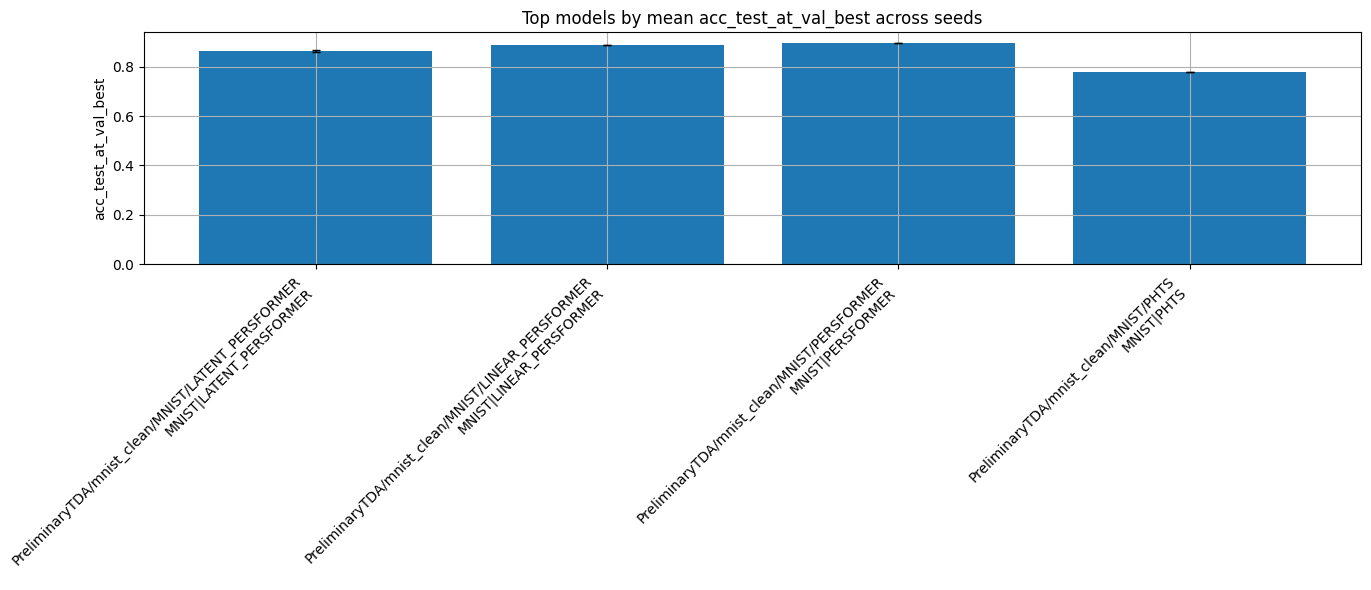

In [20]:
if acc_summary.empty:
    print("No accuracy data to plot.")
else:
    top_n = 20
    plot_df = acc_summary.head(top_n).copy()
    plot_df["label"] = (
        plot_df["experiment_name"].astype(str)
        + "\n"
        + plot_df["params.dataset"].astype(str)
        + "|"
        + plot_df["params.model"].astype(str)
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(range(len(plot_df)), plot_df["mean"], yerr=plot_df["std"].fillna(0.0), capsize=3)
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")
    ax.set_ylabel("acc_test_at_val_best")
    ax.set_title("Top models by mean acc_test_at_val_best across seeds")
    plt.tight_layout()
    plt.show()

In [13]:
metric_keys = ["loss_train", "loss_val"]

series_rows = []
if not runs_df.empty:
    meta_cols = ["run_id", "experiment_name", "params.dataset", "params.model", "params.seed"]
    run_meta = runs_df[meta_cols].drop_duplicates("run_id")

    for _, row in run_meta.iterrows():
        run_id = row["run_id"]
        for metric_key in metric_keys:
            history = client.get_metric_history(run_id, metric_key)
            for point in history:
                series_rows.append(
                    {
                        "run_id": run_id,
                        "experiment_name": row["experiment_name"],
                        "dataset": row.get("params.dataset"),
                        "model": row.get("params.model"),
                        "seed": row.get("params.seed"),
                        "metric_key": metric_key,
                        "step": point.step,
                        "value": point.value,
                    }
                )

series_df = pd.DataFrame(series_rows)
print("series rows:", len(series_df))
if not series_df.empty:
    display(series_df.head(20))

series rows: 20


,run_id,experiment_name,dataset,model,seed,metric_key,step,value
0,155237e2f49a44f4b1d242d8f2f53032,PreliminaryTDA/mnist_clean/MNIST/PERSFORMER,MNIST,PERSFORMER,0,loss_train,0,1.130957
1,155237e2f49a44f4b1d242d8f2f53032,PreliminaryTDA/mnist_clean/MNIST/PERSFORMER,MNIST,PERSFORMER,0,loss_train,1,0.544418
2,155237e2f49a44f4b1d242d8f2f53032,PreliminaryTDA/mnist_clean/MNIST/PERSFORMER,MNIST,PERSFORMER,0,loss_val,0,0.640178
3,155237e2f49a44f4b1d242d8f2f53032,PreliminaryTDA/mnist_clean/MNIST/PERSFORMER,MNIST,PERSFORMER,0,loss_val,1,0.371501
4,186f3520f440421ea6f570f38104fed2,PreliminaryTDA/mnist_clean/MNIST/PHTS,MNIST,PHTS,0,loss_train,0,1.742169
5,186f3520f440421ea6f570f38104fed2,PreliminaryTDA/mnist_clean/MNIST/PHTS,MNIST,PHTS,0,loss_train,1,1.165680
6,186f3520f440421ea6f570f38104fed2,PreliminaryTDA/mnist_clean/MNIST/PHTS,MNIST,PHTS,0,loss_val,0,1.096726
7,186f3520f440421ea6f570f38104fed2,PreliminaryTDA/mnist_clean/MNIST/PHTS,MNIST,PHTS,0,loss_val,1,0.773061
8,38de0962218648d6901cc3b4d8b0c31b,PreliminaryTDA/mnist_clean/MNIST/PS,MNIST,None,0,loss_train,0,2.054046
9,38de0962218648d6901cc3b4d8b0c31b,PreliminaryTDA/mnist_clean/MNIST/PS,MNIST,None,0,loss_train,1,1.635878


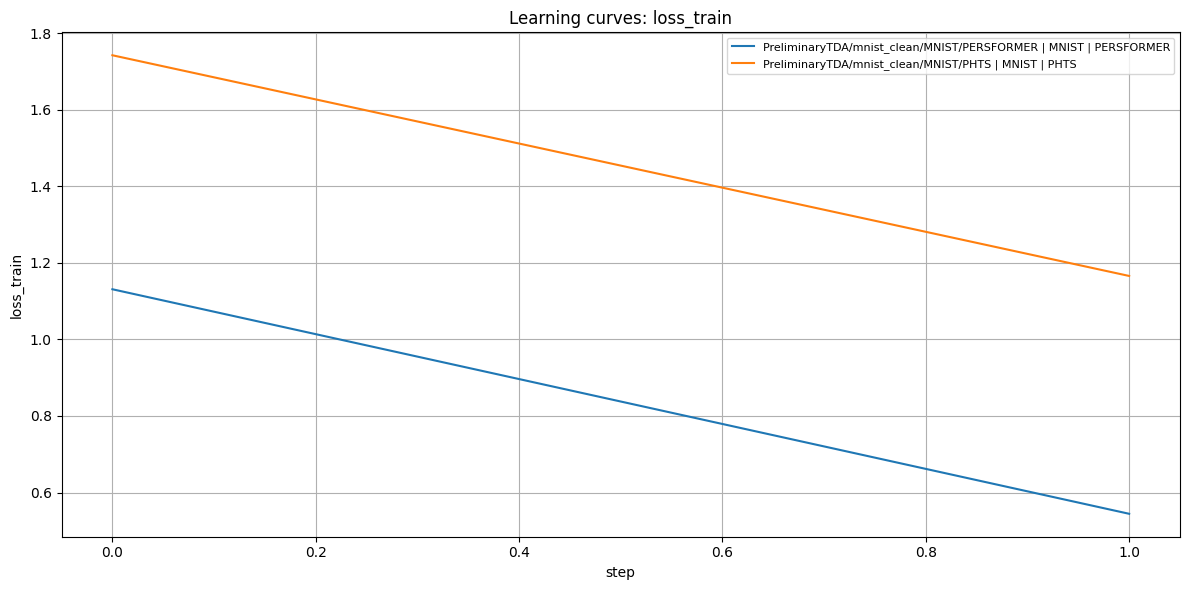

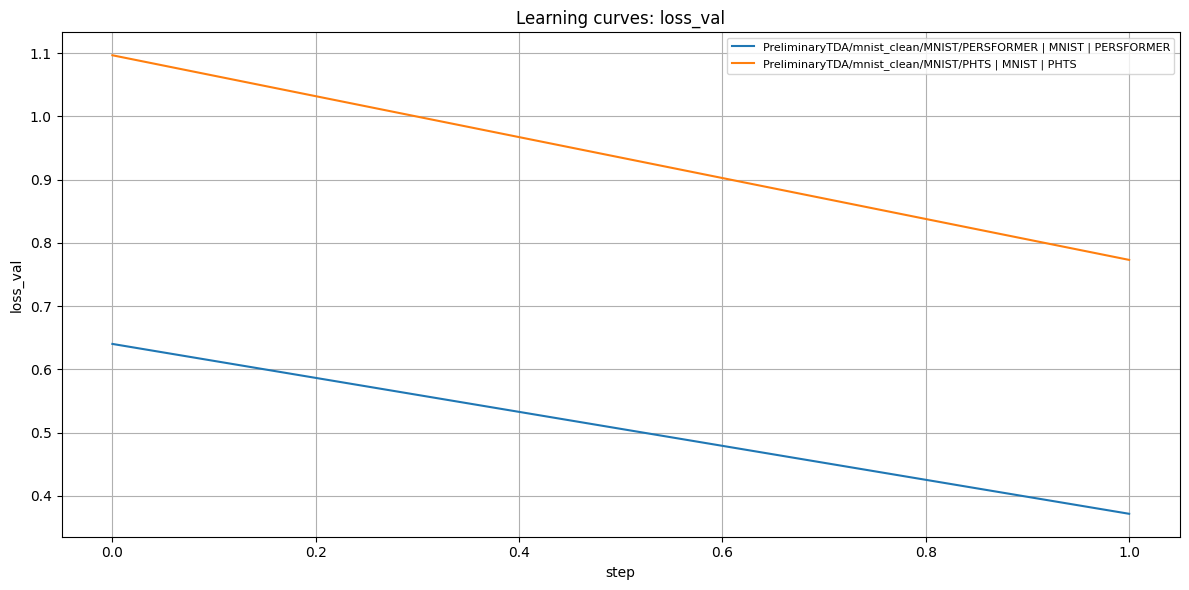

In [14]:
if series_df.empty:
    print("No metric history found for loss_train/loss_val.")
else:
    top_models = (
        runs_df[["experiment_name", "params.dataset", "params.model"]]
        .dropna()
        .drop_duplicates()
        .head(8)
    )

    plot_df = series_df.merge(
        top_models,
        left_on=["experiment_name", "dataset", "model"],
        right_on=["experiment_name", "params.dataset", "params.model"],
        how="inner",
    )

    for metric_key in ["loss_train", "loss_val"]:
        metric_df = plot_df[plot_df["metric_key"] == metric_key].copy()
        if metric_df.empty:
            print(f"No points for {metric_key}")
            continue

        agg = (
            metric_df.groupby(["experiment_name", "dataset", "model", "step"], as_index=False)["value"]
            .agg(mean="mean", std="std")
            .sort_values("step")
        )

        fig, ax = plt.subplots(figsize=(12, 6))
        for (exp_name, dataset, model), group in agg.groupby(["experiment_name", "dataset", "model"]):
            label = f"{exp_name} | {dataset} | {model}"
            ax.plot(group["step"], group["mean"], label=label)
            ax.fill_between(
                group["step"],
                group["mean"] - group["std"].fillna(0.0),
                group["mean"] + group["std"].fillna(0.0),
                alpha=0.15,
            )

        ax.set_title(f"Learning curves: {metric_key}")
        ax.set_xlabel("step")
        ax.set_ylabel(metric_key)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

In [15]:
if runs_df.empty:
    print("Nothing to diagnose: no runs loaded.")
else:
    info = runs_df.groupby(["experiment_name", "params.dataset", "params.model"], as_index=False)["run_id"].count()
    info = info.rename(columns={"run_id": "n_runs"}).sort_values("n_runs", ascending=False)
    display(info.head(30))

if not series_df.empty:
    coverage = (
        series_df.groupby(["experiment_name", "dataset", "model", "metric_key"], as_index=False)["step"]
        .nunique()
        .rename(columns={"step": "n_steps"})
        .sort_values("n_steps", ascending=False)
    )
    display(coverage.head(30))

,experiment_name,params.dataset,params.model,n_runs
0,PreliminaryTDA/mnist_clean/MNIST/PERSFORMER,MNIST,PERSFORMER,1
1,PreliminaryTDA/mnist_clean/MNIST/PHTS,MNIST,PHTS,1


,experiment_name,dataset,model,metric_key,n_steps
0,PreliminaryTDA/mnist_clean/MNIST/PERSFORMER,MNIST,PERSFORMER,loss_train,2
1,PreliminaryTDA/mnist_clean/MNIST/PERSFORMER,MNIST,PERSFORMER,loss_val,2
2,PreliminaryTDA/mnist_clean/MNIST/PHTS,MNIST,PHTS,loss_train,2
3,PreliminaryTDA/mnist_clean/MNIST/PHTS,MNIST,PHTS,loss_val,2
